In [37]:
# =================================
# STEP 3: EDA & FEATURE ENGINEERING
# =================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Add project root to path to use methods from src.utils
sys.path.append(os.path.abspath(".."))
from src.data_preprocessing import *

# Load your dataset
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCI.csv', delimiter=';')

# Drop 'unnamed' columns using regex in filter
df = df.drop(df.filter(regex="Unnamed").columns, axis=1)

# Select rows with no data
rows_to_drop: list = []
is_nan: tuple[np.ndarray, np.ndarray] = np.where(pd.isnull(df)) # tuple[np.ndarray -> indices of column, np.ndarray -> indices of rows]
for i_row, i_col in zip(is_nan[0], is_nan[1]):
    if i_row not in rows_to_drop:
        rows_to_drop.append(i_row) # rows with no data in csv-file

# Drop rows with NaN
df = df.drop(index=rows_to_drop)

# Shape: 9357 rows × 15 columns => NO missing values!
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMissing Values:\n{df.isnull().sum()}")


Shape: 9357 rows × 15 columns

Missing Values:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [38]:
# =====================================
# STEP 3: DATA CLEANING and PREPARATION
# =====================================

# Analyze columns: 'Date' and 'Time'
''' 
    1. Found no missing values 
    2. Converting dtype 'object' to dtype 'DateTime' by merging both
    3. Creating new column: 'DateTime'
    4. Drop columns: 'Date' and 'Time' afterwards
'''
df.insert(0, "DateTime",  pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S'))
df = df.drop(columns=['Date', 'Time'])

In [39]:
# Clean and transform column: 'CO(GT)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['CO(GT)_to_float'] = df['CO(GT)'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['CO(GT)_to_float'] = df['CO(GT)_to_float'].replace(-200, np.nan)
df['CO(GT)'] = df['CO(GT)_to_float']
df = df.drop(columns=['CO(GT)_to_float'])
df['CO(GT)'] = df['CO(GT)'].interpolate(method='linear', limit_direction='both')
df['CO(GT)'] = df['CO(GT)'].round(2) # Round column to 2 decimal places

In [40]:
# Clean and transform column: 'PT08.S1(CO)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S1(CO)'] = df['PT08.S1(CO)'].replace(-200, np.nan)
df['PT08.S1(CO)'] = df['PT08.S1(CO)'].interpolate(method='linear', limit_direction='both')
df['PT08.S1(CO)'] = df['PT08.S1(CO)'].round(2) # Round column to 2 decimal places

In [41]:
# Drop column: 'NMHC(GT)' - 90% of data is missing
df = df.drop(columns=['NMHC(GT)'])

In [42]:
# Clean and transform column: 'C6H6(GT)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['C6H6(GT)_to_float'] = df['C6H6(GT)'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['C6H6(GT)_to_float'] = df['C6H6(GT)_to_float'].replace(-200, np.nan)
df['C6H6(GT)'] = df['C6H6(GT)_to_float']
df = df.drop(columns=['C6H6(GT)_to_float'])
df['C6H6(GT)'] = df['C6H6(GT)'].interpolate(method='linear', limit_direction='both')
df['C6H6(GT)'] = df['C6H6(GT)'].round(2) # Round column to 2 decimal places

In [43]:
# Clean and transform column: 'PT08.S2(NMHC)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S2(NMHC)'] = df['PT08.S2(NMHC)'].replace(-200, np.nan)
df['PT08.S2(NMHC)'] = df['PT08.S2(NMHC)'].interpolate(method='linear', limit_direction='both')
df['PT08.S2(NMHC)'] = df['PT08.S2(NMHC)'].round(2) # Round column to 2 decimal places

In [44]:
# Clean and transform column: 'NOx(GT)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['NOx(GT)'] = df['NOx(GT)'].replace(-200, np.nan)
df['NOx(GT)'] = df['NOx(GT)'].interpolate(method='linear', limit_direction='both')
df['NOx(GT)'] = df['NOx(GT)'].round(2) # Round column to 2 decimal places

In [45]:
# Clean and transform column: 'PT08.S3(NOx)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S3(NOx)'] = df['PT08.S3(NOx)'].replace(-200, np.nan)
df['PT08.S3(NOx)'] = df['PT08.S3(NOx)'].interpolate(method='linear', limit_direction='both')
df['PT08.S3(NOx)'] = df['PT08.S3(NOx)'].round(2) # Round column to 2 decimal places

In [46]:
# Clean and transform column: 'NO2(GT)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['NO2(GT)'] = df['NO2(GT)'].replace(-200, np.nan)
df['NO2(GT)'] = df['NO2(GT)'].interpolate(method='linear', limit_direction='both')
df['NO2(GT)'] = df['NO2(GT)'].round(2) # Round column to 2 decimal places

In [47]:
# Clean and transform column: 'PT08.S4(NO2)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S4(NO2)'] = df['PT08.S4(NO2)'].replace(-200, np.nan)
df['PT08.S4(NO2)'] = df['PT08.S4(NO2)'].interpolate(method='linear', limit_direction='both')
df['PT08.S4(NO2)'] = df['PT08.S4(NO2)'].round(2) # Round column to 2 decimal places

In [48]:
# Clean and transform column: 'PT08.S5(O3)'
# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S5(O3)'] = df['PT08.S5(O3)'].replace(-200, np.nan)
df['PT08.S5(O3)'] = df['PT08.S5(O3)'].interpolate(method='linear', limit_direction='both')
df['PT08.S5(O3)'] = df['PT08.S5(O3)'].round(2) # Round column to 2 decimal places

In [49]:
# Clean and transform column: 'T' (Temperature)
# Replace each '-200' with NaN and interpolate the missing value(s)
df['T_to_float'] = df['T'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['T_to_float'] = df['T_to_float'].replace(-200, np.nan)
df['T'] = df['T_to_float']
df = df.drop(columns=['T_to_float'])
df['T'] = df['T'].interpolate(method='linear', limit_direction='both')
df['T'] = df['T'].round(2) # Round column to 2 decimal places

In [50]:
# Clean and transform column: 'RH' (Rel. Humidity)
# Replace each '-200' with NaN and interpolate the missing value(s)
df['RH_to_float'] = df['RH'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['RH_to_float'] = df['RH_to_float'].replace(-200, np.nan)
df['RH'] = df['RH_to_float']
df = df.drop(columns=['RH_to_float'])
df['RH'] = df['RH'].interpolate(method='linear', limit_direction='both')
df['RH'] = df['RH'].round(2) # Round column to 2 decimal places

In [51]:
# Analyze column: 'AH' (Abs. Humidity)
# Replace each '-200' with NaN and interpolate the missing value(s)
df['AH_to_float'] = df['AH'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['AH_to_float'] = df['AH_to_float'].replace(-200, np.nan)
df['AH'] = df['AH_to_float']
df = df.drop(columns=['AH_to_float'])
df['AH'] = df['AH'].interpolate(method='linear', limit_direction='both')
df['AH'] = df['AH'].round(2) # Round column to 2 decimal places

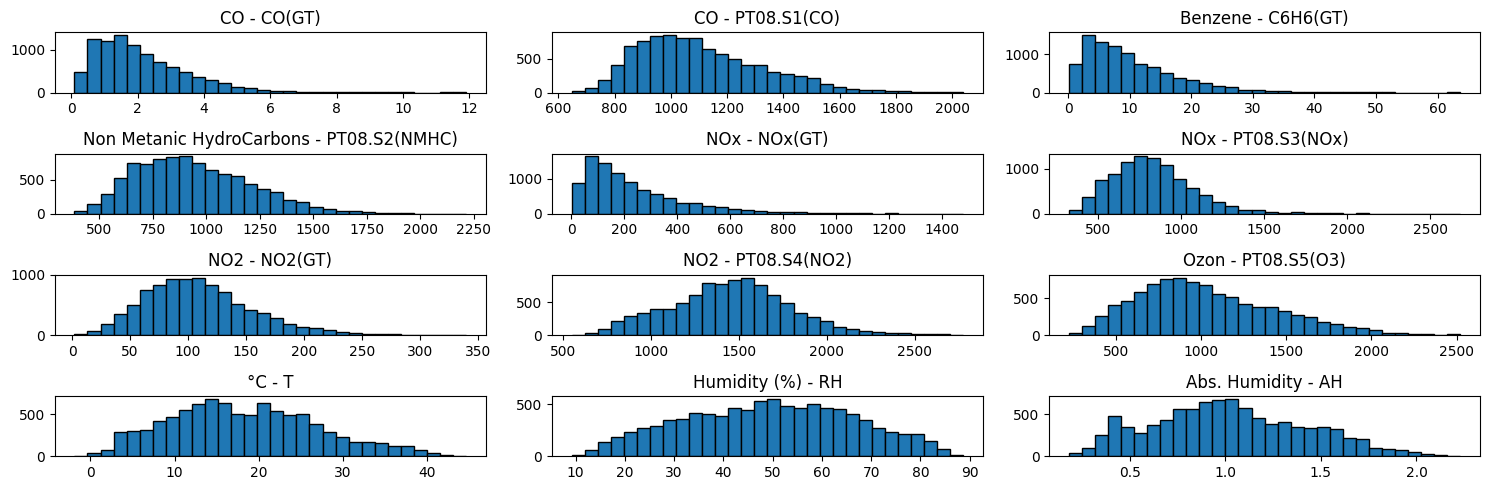

In [52]:
# Distribution plotting
def plot_distributions(df, columns, figsize=(15, 5)):
    """Plot distributions of specified columns."""
    n_cols = min(3, len(columns))
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for idx, col in enumerate(columns):
        if df[col].dtype in ['int64', 'float64']:
            axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black')
        else:
            df[col].value_counts().plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'{get_label_short(col)} - {col}')

    plt.tight_layout()
    plt.show()

# Only print columns that will be used for model training later
columns = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
plot_distributions(df, columns)

In [53]:
# STEP 4: Adding new Features

# Feature: Weekday or Weekend - Values: 0-6
df["IsWeekend"] = df["DateTime"].dt.dayofweek >= 5 # Saturday: 5, Sunday: 6
df["IsWeekday"] = df["DateTime"].dt.dayofweek < 5 # Monday: 0, Tuesday: 1 ...

# Feature: Month - Values: 1-12
df.insert(1, "Month",  df["DateTime"].dt.month)

# Feature: Hour of day - Values: 0-24
df.insert(2, "HourOfDay",  df["DateTime"].dt.hour)

# Save cleaned and transformed dataset
df.to_csv('../data/AirQualityUCIProcessed.csv', index=False)

# Feature: Threshold was risen - Values: True, False - only available for 'CO(GT)', 'C6H6(GT)', 'NO2(GT)' and 'PT08.S5(O3)'
columns_with_threshold = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)']
for column in columns_with_threshold:
    threshold_value: int | None = get_threshold(column)
    if threshold_value is not None:
        df[f'{column}ToHigh'] = np.where(df[column] > threshold_value, True, False) # e.g. 'CO(GT)ToHigh'

# Save cleaned and transformed dataset with threshold columns
df.to_csv('../data/AirQualityUCIProcessedWithThresholds.csv', index=False)

# Print all columns
for col in df.columns:
    print(col)

DateTime
Month
HourOfDay
CO(GT)
PT08.S1(CO)
C6H6(GT)
PT08.S2(NMHC)
NOx(GT)
PT08.S3(NOx)
NO2(GT)
PT08.S4(NO2)
PT08.S5(O3)
T
RH
AH
IsWeekend
IsWeekday
CO(GT)ToHigh
C6H6(GT)ToHigh
NO2(GT)ToHigh
PT08.S5(O3)ToHigh


In [54]:
# Save cleaned and transformed dataset
df.to_csv('../data/AirQualityUCIProcessed.csv', index=False)